In [47]:
import pandas as pd
import sys
import glob
from pathlib import Path

In [48]:
#path = "../expected_runs/"
#sys.path.append(path)

In [49]:
from expected_runs.generate_gamestate_summary import *

In [54]:
from expected_runs.Helpers import *
from expected_runs.target_and_calculated_pipeline import build_final_dataset
#from generate_gamestate_summary import *
from expected_runs.filter_pitch_type import *
from expected_runs.random_forest_modeling import *

In [51]:
base_path = "../../v3"
years=["2024"]
out_dir="../results/CSV_files"

In [52]:
pwd

'/home/abhin/projects/01_jack/expected-runs/JupyterNotebook'

In [7]:
summary_df = build_gamestate_summary_all_years(base_path, out_dir)


Processing 2024-02 from local files ...

Processing 2024-03 from local files ...

Processing 2024-04 from local files ...

Processing 2024-05 from local files ...

Processing 2024-06 from local files ...

Processing 2024-07 from local files ...

Processing 2024-08 from local files ...

Processing 2024-09 from local files ...

Processing 2024-10 from local files ...

Processing 2024-11 from local files ...

Processing 2024-12 from local files ...

Processing 2025-01 from local files ...

Processing 2025-02 from local files ...

Processing 2025-03 from local files ...

Processing 2025-04 from local files ...

Processing 2025-05 from local files ...

Processing 2025-06 from local files ...

Processing 2025-07 from local files ...

Processing 2025-08 from local files ...

All-year summary saved: ../results/CSV_files/GameState_Summary_ALL_prob_20260629_1118.csv


In [28]:
summary_path = glob.glob(out_dir + "/GameState_Summary*.csv")
#summary_path="../results/CSV_files/GameState_Summary.csv"
summary_path = summary_path
summary_path

['../results/CSV_files/GameState_Summary_ALL_prob_20260629_1118.csv',
 '../results/CSV_files/GameState_Summary_ALL_prob_20260602_1016.csv',
 '../results/CSV_files/GameState_Summary_ALL_prob_20260601_1605.csv',
 '../results/CSV_files/GameState_Summary_ALL_prob_20260624_1616.csv']

In [11]:
final_df = build_final_dataset(base_path, years, summary_path, out_dir)

Processing year 2024
Processing year 2025
Final dataset saved: ../results/CSV_files/Final_Target_Calc_1201.csv


In [12]:
final_df.head()

,PitchNo,Date,PAofInning,PitchofPA,Pitcher,PitcherId,PitcherThrows,PitcherTeam,Batter,BatterSide,...,Avg_HorzBreak_FastestType,Avg_RelSpeed_FastestType,vertbreakdiff,horzbreakdiff,velocity_differential,VertBreak,PlateLocHeight,PlateLocSide,Level,League
0,1.0,2024-02-09,1.0,1.0,"Avila, Cesar",1.000081e+09,Right,CUM_PAT,"Junker, Noah",Left,...,9.765045,90.629884,0.280553,1.354375,0.221296,-16.16969,0.54762,0.27288,NAIA,NAIA
1,2.0,2024-02-09,1.0,2.0,"Avila, Cesar",1.000081e+09,Right,CUM_PAT,"Junker, Noah",Left,...,9.765045,90.629884,-0.150627,0.555475,0.655266,-15.50910,2.80661,1.36947,NAIA,NAIA
2,3.0,2024-02-09,1.0,3.0,"Avila, Cesar",1.000081e+09,Right,CUM_PAT,"Junker, Noah",Left,...,9.765045,90.629884,-6.131107,3.637005,-10.341544,-31.73368,2.67172,0.58232,NAIA,NAIA
3,4.0,2024-02-09,1.0,4.0,"Avila, Cesar",1.000081e+09,Right,CUM_PAT,"Junker, Noah",Left,...,9.765045,90.629884,0.242723,-0.368265,1.151726,-15.08906,3.05884,0.02117,NAIA,NAIA
4,5.0,2024-02-09,2.0,1.0,"Avila, Cesar",1.000081e+09,Right,CUM_PAT,"Sibert, Gabe",Right,...,9.765045,90.629884,2.507603,-0.442405,1.165276,-13.08162,2.37370,-0.03395,NAIA,NAIA


In [13]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M")

In [20]:
output_dir = Path(out_dir)

In [21]:
ff_output_path = output_dir / f"df_ff_{timestamp}.csv"
ff_output_path

PosixPath('../results/CSV_files/df_ff_20260629_1211.csv')

In [22]:
team_output_path = output_dir / f"df_del_blu_ff_{timestamp}.csv"
team_output_path

PosixPath('../results/CSV_files/df_del_blu_ff_20260629_1211.csv')

In [25]:
ff_output_path, team_output_path = get_timestamped_output_paths(out_dir)

In [32]:
target_paths = glob.glob(out_dir + "/Final_Target_Calc_*.csv")
input_file = target_paths[-1]
input_file

'../results/CSV_files/Final_Target_Calc_1201.csv'

In [31]:
final_df = create_ff_dataset(input_path=input_file, output_path=ff_output_path)

In [33]:
final_df

,PitchNo,Date,PAofInning,PitchofPA,Pitcher,PitcherId,PitcherThrows,PitcherTeam,Batter,BatterSide,...,Avg_RelSpeed_FastestType,vertbreakdiff,horzbreakdiff,velocity_differential,VertBreak,PlateLocHeight,PlateLocSide,Level,League,PitchBucket
0,1.0,2024-02-09,1.0,1.0,"Avila, Cesar",1.000081e+09,Right,CUM_PAT,"Junker, Noah",Left,...,90.629884,0.280553,1.354375,0.221296,-16.16969,0.54762,0.27288,NAIA,NAIA,FourSeamFastball
1,2.0,2024-02-09,1.0,2.0,"Avila, Cesar",1.000081e+09,Right,CUM_PAT,"Junker, Noah",Left,...,90.629884,-0.150627,0.555475,0.655266,-15.50910,2.80661,1.36947,NAIA,NAIA,FourSeamFastball
3,4.0,2024-02-09,1.0,4.0,"Avila, Cesar",1.000081e+09,Right,CUM_PAT,"Junker, Noah",Left,...,90.629884,0.242723,-0.368265,1.151726,-15.08906,3.05884,0.02117,NAIA,NAIA,FourSeamFastball
4,5.0,2024-02-09,2.0,1.0,"Avila, Cesar",1.000081e+09,Right,CUM_PAT,"Sibert, Gabe",Right,...,90.629884,2.507603,-0.442405,1.165276,-13.08162,2.37370,-0.03395,NAIA,NAIA,FourSeamFastball
7,8.0,2024-02-09,2.0,4.0,"Avila, Cesar",1.000081e+09,Right,CUM_PAT,"Sibert, Gabe",Right,...,90.629884,-2.187757,-4.628545,-0.805534,-18.44973,5.11803,0.55275,NAIA,NAIA,FourSeamFastball
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3563840,244.0,2024-05-16,1.0,4.0,"Manning, Grant",1.000128e+09,Right,VIR_TEC,"Whalen, Robert",Right,...,91.231013,-1.026766,0.388798,-0.767473,-19.17214,2.34006,0.03954,D1,ACC,FourSeamFastball
3563841,245.0,2024-05-16,1.0,5.0,"Manning, Grant",1.000128e+09,Right,VIR_TEC,"Whalen, Robert",Right,...,91.231013,-1.135346,0.311238,0.455597,-18.79446,2.48907,-0.07174,D1,ACC,FourSeamFastball
3563847,251.0,2024-05-16,2.0,6.0,"Manning, Grant",1.000128e+09,Right,VIR_TEC,"O'Ferrall, Griff",Right,...,91.231013,0.229774,0.522148,2.227427,-16.06351,3.44298,0.06199,D1,ACC,FourSeamFastball
3563849,253.0,2024-05-16,3.0,1.0,"Manning, Grant",1.000128e+09,Right,VIR_TEC,"Anderson, Ethan",Left,...,91.231013,-0.210036,2.886868,3.132617,-15.94717,2.04500,0.62883,D1,ACC,FourSeamFastball


In [42]:
input_paths = glob.glob(out_dir + "/df_ff_*.csv")
input_paths

['../results/CSV_files/df_ff_20260629_1218.csv']

In [55]:
rf = RandomForestRegressor(
    n_estimators=100,      
    max_depth=5,        
    random_state=42,       
    n_jobs=-1,             
)                          

In [ ]:
#model, train_results, test_results = train_random_forest_model(input_path=input_paths[0], model_path=out_dir+f"/model_{timestamp}.csv")

In [45]:
out_dir+f"/model_{timestamp}.csv"

'../results/CSV_files/model_20260629_1211.csv'

In [57]:
df_ff = pd.read_csv(input_paths[0])

In [58]:
X = df_ff[FEATURE_COLUMNS]
y = df_ff[TARGET_COLUMN]

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X,                                              
    y,                                              
    test_size=0.2,                                  
    random_state=42,                                
)                                                   

In [81]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [82]:
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

In [83]:
train_metrics = evaluate_predictions(y_train, y_train_pred)
test_metrics = evaluate_predictions(y_test, y_test_pred)

In [84]:
train_metrics

{'MAE': 0.17327352942316512,
 'RMSE': np.float64(0.2600000711394603),
 'R2': 0.0010452858845552138}

In [85]:
test_metrics

{'MAE': 0.1732219486541338,
 'RMSE': np.float64(0.2602910119679747),
 'R2': 0.00043693837316460815}

In [66]:
from sklearn.dummy import DummyRegressor

In [68]:
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)

,"strategy strategy: {""mean"", ""median"", ""quantile"", ""constant""}, default=""mean""Strategy to use to generate predictions.* ""mean"": always predicts the mean of the training set* ""median"": always predicts the median of the training set* ""quantile"": always predicts a specified quantile of the training set, provided with the quantile parameter.* ""constant"": always predicts a constant value that is provided by the user.",'mean'
,"constant constant: int or float or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
,"quantile quantile: float in [0.0, 1.0], default=NoneThe quantile to predict using the ""quantile"" strategy. A quantile of0.5 corresponds to the median, while 0.0 to the minimum and 1.0 to themaximum.",None


In [69]:
pred = dummy.predict(X_test)

In [71]:
evaluate_predictions(y_test, pred)

{'MAE': 0.17362522011296916,
 'RMSE': np.float64(0.2604629359682532),
 'R2': -4.721644135674552e-07}

In [74]:
y.describe()

count    1.661367e+06
mean    -4.750474e-02
std      2.601785e-01
min     -3.004400e+00
25%     -1.380000e-01
50%     -3.690000e-02
75%      7.510000e-02
max      1.904900e+00
Name: Target, dtype: float64

<Axes: >

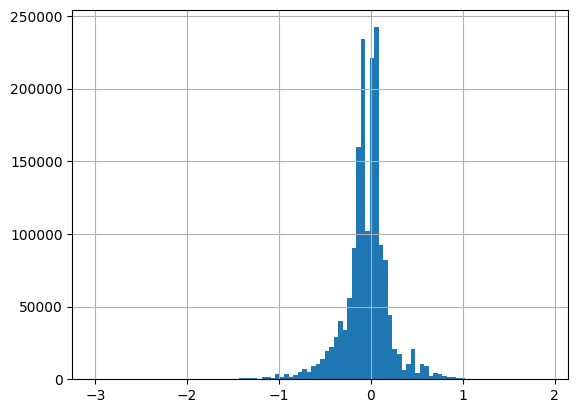

In [78]:
y.hist(bins=100)

In [79]:
print(y.mean())
print(y.std())

print((abs(y) < 0.05).mean())
print((abs(y) < 0.10).mean())

-0.047504744466454425
0.26017854601417306
0.18813121965225021
0.4714755981068602
